In [1]:
import tensorflow as tf
import numpy as np
import random
import os
import json
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    balanced_accuracy_score
)

from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau,
    EarlyStopping,
    ModelCheckpoint,
    CSVLogger
)

I0000 00:00:1779909156.974013    5329 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779909157.172840    5329 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779909158.525220    5329 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [ ]:
SEED = 2006
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [3]:

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        try:
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError as e:
            print(f"GPU memory growth setting skipped: {e}")

In [4]:
import tensorflow as tf
print(tf.__version__)
print(tf.config.list_physical_devices())
print(tf.config.list_physical_devices('GPU'))

2.21.0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [5]:
from tensorflow.keras import mixed_precision

mixed_precision.set_global_policy('mixed_float16')

In [6]:
IMAGE_SIZE = (224, 224)

BATCH_SIZE = 32

EPOCHS = 100

LEARNING_RATE = 0.0001

DATASET_PATH = "../Mendeley_Dataset"

RESULTS_DIR = "results_4"

os.makedirs(RESULTS_DIR, exist_ok=True)

In [7]:
# train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(

#     rescale=1./255,

#     rotation_range=40,

#     zoom_range=[0, 0.3],

#     horizontal_flip=True,

#     vertical_flip=True,

#     validation_split=0.2
# )

# val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(

#     rescale=1./255,

#     validation_split=0.2
# )

In [8]:
# train_generator = train_datagen.flow_from_directory(

#     DATASET_PATH,

#     target_size=IMAGE_SIZE,

#     batch_size=BATCH_SIZE,

#     class_mode='categorical',

#     subset='training',

#     shuffle=True,

#     seed=SEED
# )

In [9]:
# val_generator = val_datagen.flow_from_directory(

#     DATASET_PATH,

#     target_size=IMAGE_SIZE,

#     batch_size=BATCH_SIZE,

#     class_mode='categorical',

#     subset='validation',

#     shuffle=False,

#     seed=SEED
# )

# CLASS_NAMES = list(train_generator.class_indices.keys())

# NUM_CLASSES = len(CLASS_NAMES)

# print("\nClasses:")
# print(CLASS_NAMES)

In [10]:
# print(train_generator.class_indices)

# from collections import Counter

# print("Train distribution:")
# print(Counter(train_generator.classes))

# print("Validation distribution:")
# print(Counter(val_generator.classes))

In [11]:
import os
import pandas as pd
import tensorflow as tf
from pathlib import Path
from sklearn.model_selection import train_test_split

# Collect image paths and labels
DATASET_PATH = Path(DATASET_PATH)

image_paths = []
labels = []

for class_name in os.listdir(DATASET_PATH):
    class_dir = DATASET_PATH / class_name

    if class_dir.is_dir():
        for img in class_dir.iterdir():
            image_paths.append(str(img))
            labels.append(class_name)

# Stratified split
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=SEED,
    shuffle=True
)

# DataFrames
train_df = pd.DataFrame({
    'filename': train_paths,
    'class': train_labels
})

val_df = pd.DataFrame({
    'filename': val_paths,
    'class': val_labels
})

# SAME augmentation as your original code
from tensorflow.keras.applications.densenet import preprocess_input
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=40,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# Generators
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_dataframe(
    val_df,
    x_col='filename',
    y_col='class',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

CLASS_NAMES = list(train_generator.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)

Found 2460 validated image filenames belonging to 7 classes.
Found 616 validated image filenames belonging to 7 classes.
Classes: ['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']
Train samples: 2460
Validation samples: 616


In [12]:
base_model = DenseNet201(

    weights='imagenet',

    include_top=False,

    input_shape=(224, 224, 3),

    pooling='avg'
)

I0000 00:00:1779909160.206285    5329 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4132 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [13]:
# base_model.trainable = False

In [14]:
# for layer in base_model.layers[:-40]:
#     layer.trainable = False

# for layer in base_model.layers[-40:]:
#     layer.trainable = True

In [15]:
x = base_model.output

outputs = Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [16]:
optimizer = Adam(
    learning_rate=LEARNING_RATE
)

In [17]:
model.compile(

    optimizer=optimizer,

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 18,335,431 (69.94 MB)

 Trainable params: 18,106,375 (69.07 MB)

 Non-trainable params: 229,056 (894.75 KB)

In [18]:
reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    verbose=1
)

early_stop = EarlyStopping(

    monitor='val_loss',

    patience=15,

    min_delta=0.001,

    restore_best_weights=True,

    verbose=1
)

checkpoint = ModelCheckpoint(

    filepath=os.path.join(
        RESULTS_DIR,
        "best.keras"
    ),

    monitor='val_accuracy',
    mode='max',

    save_best_only=True,

    verbose=1
)

csv_logger = CSVLogger(

    os.path.join(
        RESULTS_DIR,
        "training_log.csv"
    )
)

In [19]:
import tensorflow as tf

print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [20]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=EPOCHS,

    callbacks=[
        reduce_lr,
        early_stop,
        checkpoint,
        csv_logger
    ]
)

Epoch 1/100


I0000 00:00:1779909164.145248    5329 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1779909209.906535    5631 service.cc:153] XLA service 0x7963400360b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779909209.906578    5631 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779909211.613365    5631 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779909223.315554    5631 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779909225.349420    5631 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_151227__.1851
E0000 00:00:1779909556.748718    6483 slow_operation_alarm.cc:73] 
********************************
[Compiling module a_inference_one_step_on_data_1

50/77 ━━━━━━━━━━━━━━━━━━━━ 11s 430ms/step - accuracy: 0.4519 - loss: 1.4428

I0000 00:00:1779909624.298263    5632 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_151227__.1851


77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.5167 - loss: 1.2803
Epoch 1: val_accuracy improved from None to 0.81006, saving model to results_4/best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 895s 6s/step - accuracy: 0.6703 - loss: 0.8954 - val_accuracy: 0.8101 - val_loss: 0.5314 - learning_rate: 1.0000e-04
Epoch 2/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.8328 - loss: 0.4852
Epoch 2: val_accuracy improved from 0.81006 to 0.84578, saving model to results_4/best.keras
77/77 ━━━━━━━━━━━━━━━━━━━━ 40s 520ms/step - accuracy: 0.8622 - loss: 0.4154 - val_accuracy: 0.8458 - val_loss: 0.4162 - learning_rate: 1.0000e-04
Epoch 3/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 452ms/step - accuracy: 0.8942 - loss: 0.2946
Epoch 3: val_accuracy did not improve from 0.84578
77/77 ━━━━━━━━━━━━━━━━━━━━ 41s 527ms/step - accuracy: 0.8874 - loss: 0.3062 - val_accuracy: 0.8231 - val_loss: 0.5645 - learning_rate: 1.0000e-04
Epoch 4/100
77/77 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9198 - loss: 0.23

In [21]:
model.save(
    os.path.join(
        RESULTS_DIR,
        "final.keras"
    )
)

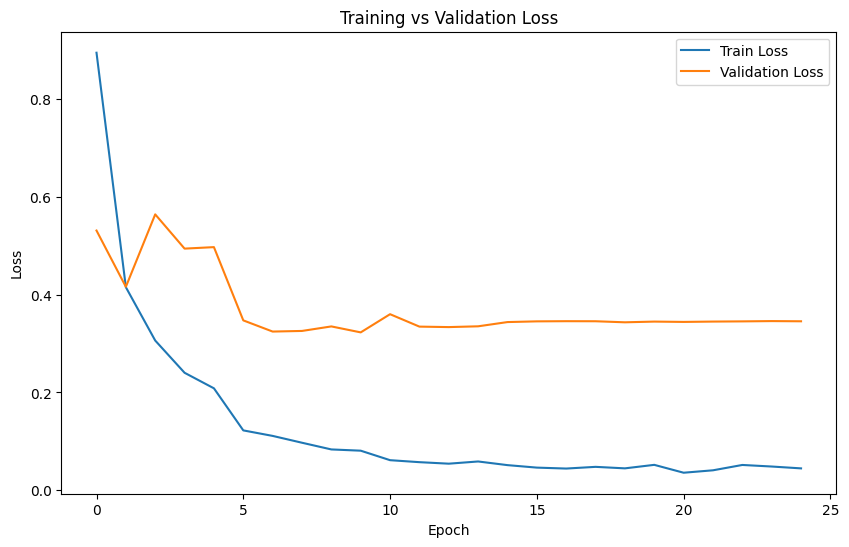

In [22]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['loss'],
    label='Train Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "loss_curve.png"
    )
)


In [23]:
plt.close()

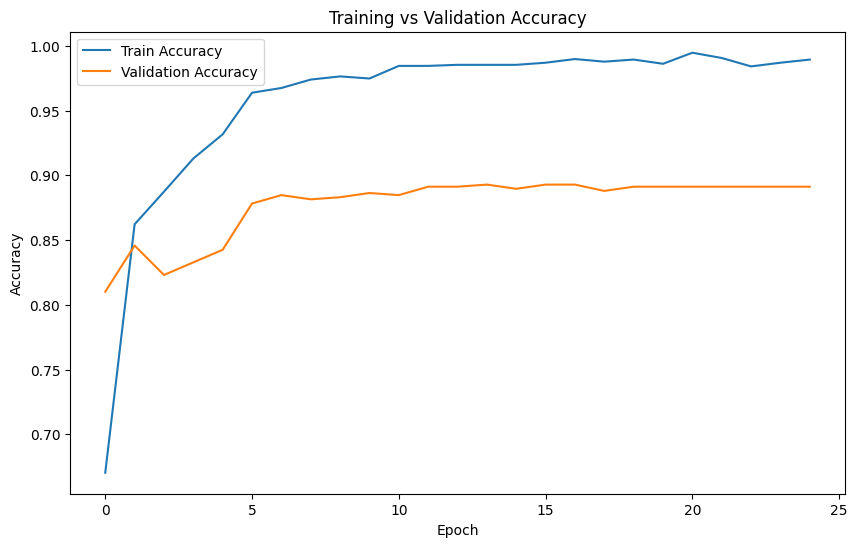

In [24]:
plt.figure(figsize=(10, 6))

plt.plot(
    history.history['accuracy'],
    label='Train Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "accuracy_curve.png"
    )
)


In [25]:

plt.close()

In [26]:
print("\nEvaluating Model...\n")

val_generator.reset()

predictions = model.predict(val_generator)

y_pred = np.argmax(predictions, axis=1)

y_true = val_generator.classes


Evaluating Model...



E0000 00:00:1779911033.856659    5329 util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


20/20 ━━━━━━━━━━━━━━━━━━━━ 30s 911ms/step


In [27]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_true,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_true,
    y_pred,
    average='weighted'
)

mcc = matthews_corrcoef(
    y_true,
    y_pred
)

balanced_acc = balanced_accuracy_score(
    y_true,
    y_pred
)

In [28]:
print("=" * 50)

print(f"Accuracy           : {accuracy*100:.2f}%")

print(f"Precision          : {precision*100:.2f}%")

print(f"Recall             : {recall*100:.2f}%")

print(f"F1 Score           : {f1*100:.2f}%")

print(f"MCC                : {mcc:.4f}")

print(f"Balanced Accuracy  : {balanced_acc*100:.2f}%")

print("=" * 50)


Accuracy           : 88.64%
Precision          : 89.07%
Recall             : 88.64%
F1 Score           : 88.69%
MCC                : 0.8619
Balanced Accuracy  : 87.63%


In [29]:
metrics = {

    "accuracy": float(accuracy),

    "precision": float(precision),

    "recall": float(recall),

    "f1_score": float(f1),

    "mcc": float(mcc),

    "balanced_accuracy": float(balanced_acc)
}

with open(
    os.path.join(
        RESULTS_DIR,
        "metrics.json"
    ),
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

In [30]:
report = classification_report(

    y_true,

    y_pred,

    target_names=CLASS_NAMES
)

print("\nClassification Report:\n")

print(report)

with open(
    os.path.join(
        RESULTS_DIR,
        "classification_report.txt"
    ),
    "w"
) as f:

    f.write(report)


Classification Report:

              precision    recall  f1-score   support

    Bacteria       0.98      0.99      0.99       114
       Fungi       0.87      0.89      0.88       150
     Healthy       0.73      0.95      0.83        40
    Nematode       0.92      0.79      0.85        14
        Pest       0.83      0.84      0.84       122
 Phytopthora       0.89      0.83      0.86        69
       Virus       0.95      0.85      0.90       107

    accuracy                           0.89       616
   macro avg       0.88      0.88      0.88       616
weighted avg       0.89      0.89      0.89       616



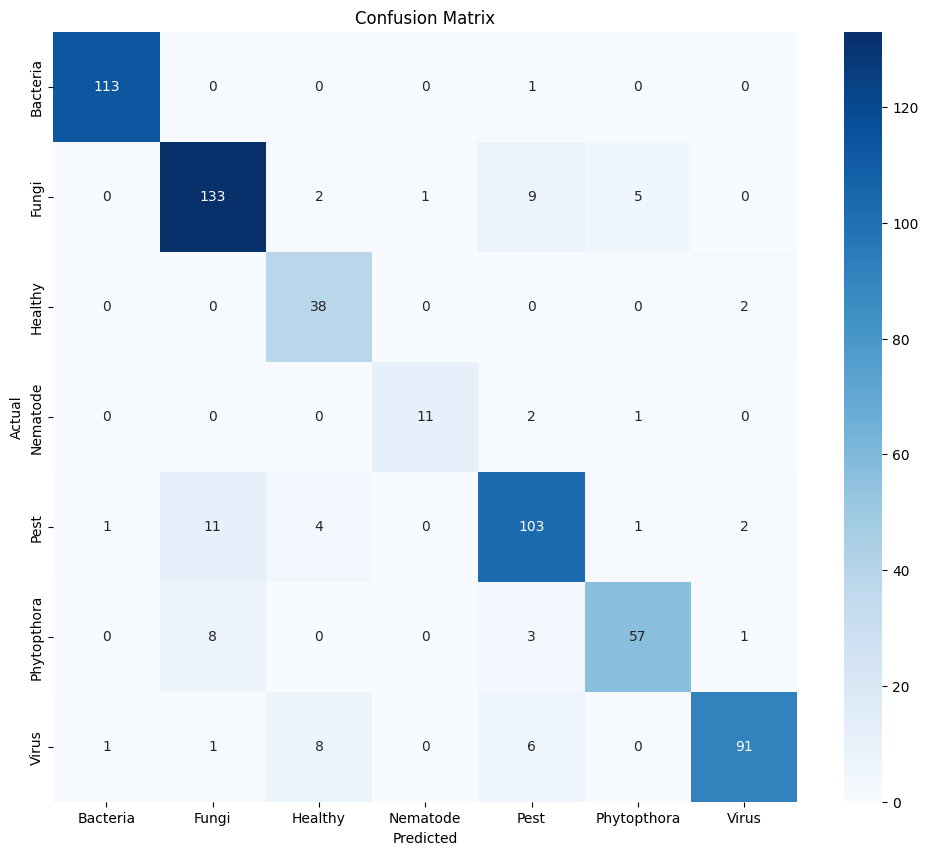

In [31]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))

sns.heatmap(

    cm,

    annot=True,

    fmt='d',

    cmap='Blues',

    xticklabels=CLASS_NAMES,

    yticklabels=CLASS_NAMES
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "confusion_matrix.png"
    )
)


In [32]:

plt.close()

In [33]:
history_dict = history.history

with open(
    os.path.join(
        RESULTS_DIR,
        "history.json"
    ),
    "w"
) as f:

    json.dump(
        history_dict,
        f,
        indent=4
    )

print("\nEverything saved in /results directory")

print("\nSaved Files:")

for file in os.listdir(RESULTS_DIR):
    print(" -", file)


Everything saved in /results directory

Saved Files:
 - final.keras
 - loss_curve.png
 - metrics.json
 - history.json
 - accuracy_curve.png
 - training_log.csv
 - confusion_matrix.png
 - best.keras
 - classification_report.txt
